<a href="https://colab.research.google.com/github/Oyips/Oyips-Analysis/blob/main/oyips_analysis_week_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Oyip's Analysis — Week 1

## Does vehicle weight affect fuel efficiency?

### Question
Is there a measurable relationship between a vehicle's weight and its fuel efficiency?

### Variables
- **Weight:** vehicle weight
- **MPG:** miles per gallon

### Approach
1. Explore the data
2. Visualize weight against MPG
3. Measure the relationship statistically
4. Build a simple mathematical model
5. Interpret the result using both data and physics

> We let the data talk.

In [ ]:

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

Dataset shape: (398, 9)

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [ ]:

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

Shape: (398, 9)

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Data types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


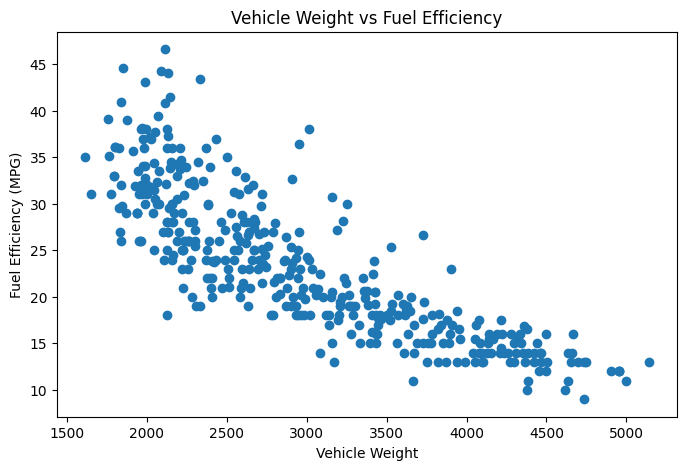

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["weight"], df["mpg"])

plt.xlabel("Vehicle Weight")
plt.ylabel("Fuel Efficiency (MPG)")
plt.title("Vehicle Weight vs Fuel Efficiency")

plt.show()

In [ ]:
correlation = df["weight"].corr(df["mpg"])

print("Correlation:", correlation)

Correlation: -0.8317409332443352


In [ ]:
slope, intercept = np.polyfit(df["weight"], df["mpg"], 1)

print("Slope:", slope)
print("Intercept:", intercept)

Slope: -0.0076766100639264765
Intercept: 46.31736442026564


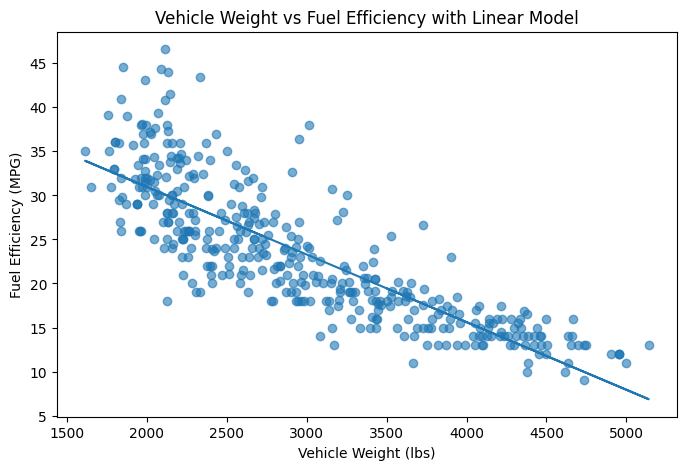

In [ ]:
predicted_mpg = intercept + slope * df["weight"]

plt.figure(figsize=(8, 5))

plt.scatter(df["weight"], df["mpg"], alpha=0.6)
plt.plot(df["weight"], predicted_mpg)

plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Fuel Efficiency (MPG)")
plt.title("Vehicle Weight vs Fuel Efficiency with Linear Model")

plt.show()

In [ ]:
r_squared = correlation ** 2

print("R²:", r_squared)
print("Percentage explained:", r_squared * 100)

R²: 0.6917929800341577
Percentage explained: 69.17929800341577


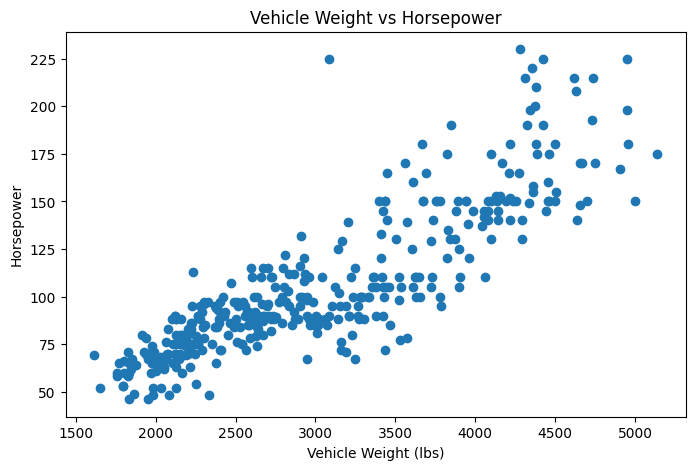

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["weight"], df["horsepower"])

plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Horsepower")
plt.title("Vehicle Weight vs Horsepower")

plt.show()

In [ ]:
weight_hp_corr = df["weight"].corr(df["horsepower"])

print("Weight–Horsepower correlation:", weight_hp_corr)

Weight–Horsepower correlation: 0.8645377375741439


In [ ]:
hp_mpg_corr = df["horsepower"].corr(df["mpg"])

print("Horsepower–MPG correlation:", hp_mpg_corr)

Horsepower–MPG correlation: -0.7784267838977756


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

X = df[["weight", "horsepower"]].dropna()
y = df.loc[X.index, "mpg"]

model.fit(X, y)

print("Weight coefficient:", model.coef_[0])
print("Horsepower coefficient:", model.coef_[1])
print("Intercept:", model.intercept_)
print("R²:", model.score(X, y))

Weight coefficient: -0.00579415736480292
Horsepower coefficient: -0.047302863086191686
Intercept: 45.64021084017712
R²: 0.7063752737298348


In [ ]:
predicted_mpg_multi = model.predict(X)
residuals = y - predicted_mpg_multi

print("Mean residual:", residuals.mean())
print("Residual standard deviation:", residuals.std())

Mean residual: 5.220313977012981e-15
Residual standard deviation: 4.229311141324016


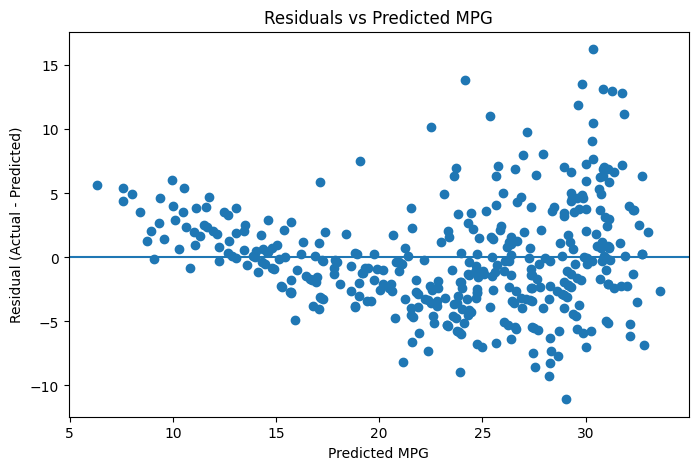

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(predicted_mpg_multi, residuals)
plt.axhline(0)

plt.xlabel("Predicted MPG")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted MPG")

plt.show()

In [ ]:
features = ["weight", "horsepower", "cylinders", "displacement"]

X2 = df[features].dropna()
y2 = df.loc[X2.index, "mpg"]

model2 = LinearRegression()
model2.fit(X2, y2)

print("Coefficients:")
for feature, coefficient in zip(features, model2.coef_):
    print(f"{feature}: {coefficient}")

print("Intercept:", model2.intercept_)
print("R²:", model2.score(X2, y2))

Coefficients:
weight: -0.005277173097701126
horsepower: -0.042812481130951305
cylinders: -0.3932854314289223
displacement: 0.0001388931287409842
Intercept: 45.756770522147946
R²: 0.7076520738329177


In [ ]:
year_mpg_corr = df["model_year"].corr(df["mpg"])

print("Model Year–MPG correlation:", year_mpg_corr)

Model Year–MPG correlation: 0.5792671330833096


In [ ]:
weight_year_corr = df["weight"].corr(df["model_year"])

print("Weight–Model Year correlation:", weight_year_corr)

Weight–Model Year correlation: -0.3065643342832895


In [ ]:
features_a = ["weight", "horsepower"]

X_a = df[features_a].dropna()
y_a = df.loc[X_a.index, "mpg"]

model_a = LinearRegression()
model_a.fit(X_a, y_a)

r2_a = model_a.score(X_a, y_a)


features_b = ["weight", "horsepower", "model_year"]

X_b = df[features_b].dropna()
y_b = df.loc[X_b.index, "mpg"]

model_b = LinearRegression()
model_b.fit(X_b, y_b)

r2_b = model_b.score(X_b, y_b)

print("R² — Weight + Horsepower:", r2_a)
print("R² — Weight + Horsepower + Model Year:", r2_b)
print("Improvement:", r2_b - r2_a)

R² — Weight + Horsepower: 0.7063752737298348
R² — Weight + Horsepower + Model Year: 0.808318914539992
Improvement: 0.10194364081015728


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

features = ["weight", "horsepower", "model_year"]

X = df[features].dropna()
y = df.loc[X.index, "mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model_test = LinearRegression()
model_test.fit(X_train, y_train)

y_pred = model_test.predict(X_test)

print("Training R²:", model_test.score(X_train, y_train))
print("Testing R²:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

Training R²: 0.8104533995566617
Testing R²: 0.7923914571293734
Test MAE: 2.508928713700655


In [ ]:
year_mpg = df.groupby("model_year")["mpg"].mean()

print(year_mpg)

model_year
70    17.689655
71    21.250000
72    18.714286
73    17.100000
74    22.703704
75    20.266667
76    21.573529
77    23.375000
78    24.061111
79    25.093103
80    33.696552
81    30.334483
82    31.709677
Name: mpg, dtype: float64


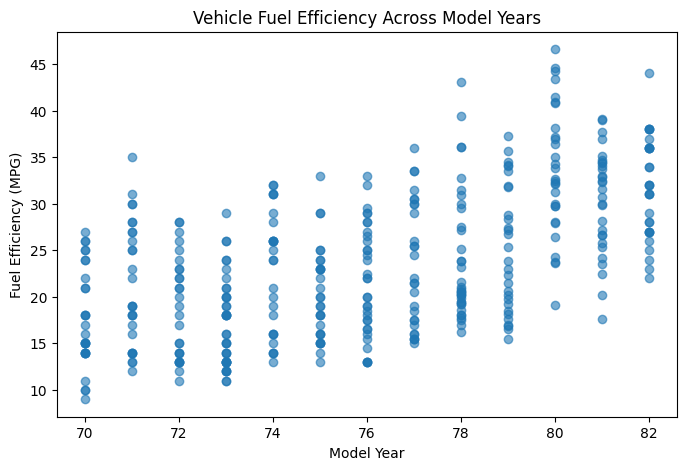

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["model_year"], df["mpg"], alpha=0.6)

plt.xlabel("Model Year")
plt.ylabel("Fuel Efficiency (MPG)")
plt.title("Vehicle Fuel Efficiency Across Model Years")

plt.show()

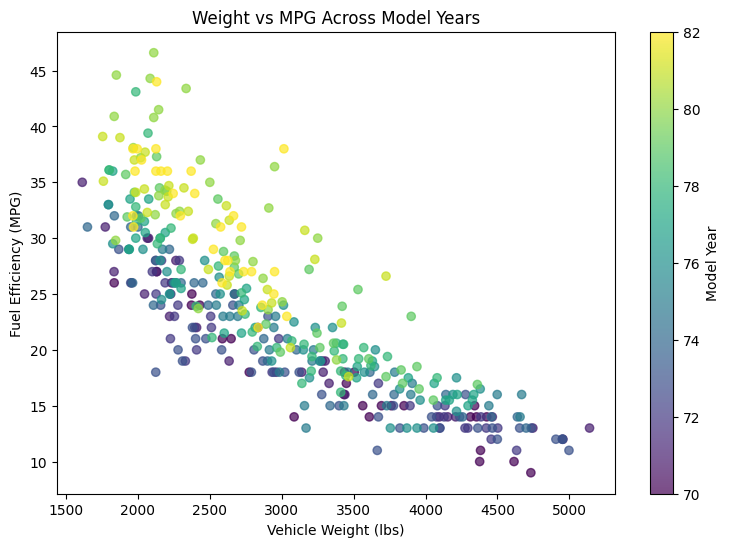

In [ ]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df["weight"],
    df["mpg"],
    c=df["model_year"],
    alpha=0.7
)

plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Fuel Efficiency (MPG)")
plt.title("Weight vs MPG Across Model Years")

plt.colorbar(scatter, label="Model Year")

plt.show()

In [ ]:
weight_year_corr = df["weight"].corr(df["model_year"])

print("Weight–Model Year correlation:", weight_year_corr)

Weight–Model Year correlation: -0.3065643342832895


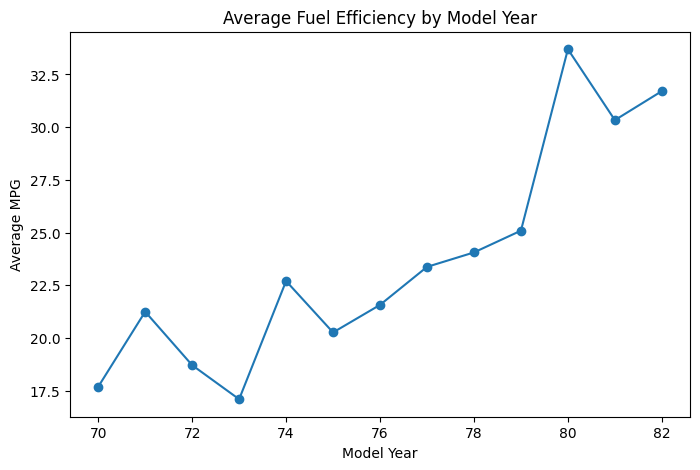

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(year_mpg.index, year_mpg.values, marker="o")

plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.title("Average Fuel Efficiency by Model Year")

plt.show()

Conclusion
Does vehicle weight affect fuel efficiency?
The analysis shows a strong negative relationship between vehicle weight and fuel efficiency.

The correlation between weight and MPG was -0.832, indicating that heavier vehicles in this dataset generally have lower fuel efficiency. A simple linear model estimated that every additional 100 lbs of vehicle weight is associated with approximately 0.77 fewer MPG.

Weight alone explained about 69.2% of the variation in MPG.

However, weight does not tell the whole story. Weight was also strongly related to horsepower, and adding horsepower to the model increased the explained variation only slightly, to about 70.6%. When model year was added, the R² increased to about 80.8%, showing that changes across vehicle generations contain substantial information about fuel efficiency.

On a held-out test set, the model achieved an R² of about 79.2% with a mean absolute error of about 2.51 MPG, suggesting that the relationships identified in the dataset have useful predictive value for similar vehicles.

What does this mean?
The data strongly supports an association between vehicle weight and fuel efficiency, but it does not prove that weight alone causes the observed differences in MPG.

Vehicle efficiency is influenced by several interconnected factors, including weight, engine characteristics, vehicle design, and technological changes over time.

From a physics perspective, the result is reasonable: moving and accelerating a heavier vehicle generally requires more energy. But the actual fuel consumed also depends on how that energy is produced and used.

The important lesson is not simply that heavier vehicles get worse fuel economy.

It is that a strong relationship in data can reveal a physical pattern, while additional variables help us understand the mechanism behind that pattern.


Oyip's Analysis — We let the data talk.